# Week 8 — Statistical Power: A Worked Example

This notebook is a worked example for Week 8 (*False Positives and Negatives / Statistical Power*). It walks through:

1. What statistical power is, in plain terms
2. Computing power analytically for a two-arm experiment (via `statsmodels`)
3. Confirming that result by simulation — actually running thousands of fake experiments and counting how often we detect a real effect
4. Working backward: how large a sample do you need for 80% power?

Run each cell top to bottom. Nothing here needs to be filled in — read it, run it, and use it as a template when you're designing your own experiment's sample size.

## The concept

Statistical power is the probability that your experiment detects a real effect, given that the effect actually exists. It depends on four things, and fixing any three determines the fourth:

- **Effect size** — how big the true difference between treatment and control is (in standardized units, Cohen's *d*)
- **Sample size** — how many units (people, plots, whatever) you assign to each arm
- **Significance level (α)** — your false-positive threshold, conventionally 0.05
- **Power (1 − β)** — your true-positive rate, conventionally targeted at 0.80

Low power is a big part of why the replication-crisis readings this week (Camerer et al., Nosek et al.) matter: an underpowered study that happens to turn up a significant result is more likely to be a false positive, and even when the effect is real, its estimated size will be inflated.

In [1]:
import numpy as np
from scipy import stats
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=6008)

## Part 1 — Analytic power calculation

Suppose you're designing a two-arm experiment (treatment vs. control) and you expect a **medium effect size** (Cohen's *d* = 0.5) — a common back-of-envelope assumption when you don't have pilot data. With 50 participants per arm and α = 0.05, what's your power?

In [2]:
effect_size = 0.5   # Cohen's d -- "medium" by convention
n_per_group = 50
alpha = 0.05

power_analysis = TTestIndPower()
power = power_analysis.power(effect_size=effect_size, nobs1=n_per_group, alpha=alpha, ratio=1.0)
print(f"Power with n={n_per_group} per arm: {power:.3f}")

Power with n=50 per arm: 0.697


That's well below the conventional 0.80 target — meaning if the true effect really is *d* = 0.5, an experiment this size would fail to detect it more often than it succeeds.

## Part 2 — Working backward: what sample size do I need?

More useful in practice: fix your target power (0.80) and effect size, and solve for the sample size you'd need per arm.

In [3]:
target_power = 0.80
required_n = power_analysis.solve_power(effect_size=effect_size, alpha=alpha, power=target_power, ratio=1.0)
print(f"Required n per arm for {target_power:.0%} power: {required_n:.1f} -> round up to {int(np.ceil(required_n))}")

Required n per arm for 80% power: 63.8 -> round up to 64


## Part 3 — Power curves

Rarely will you have just one guess at the effect size. Plotting power against sample size for a few plausible effect sizes is a good way to see the whole picture at once, and a good way to communicate the trade-off to a collaborator or reviewer.

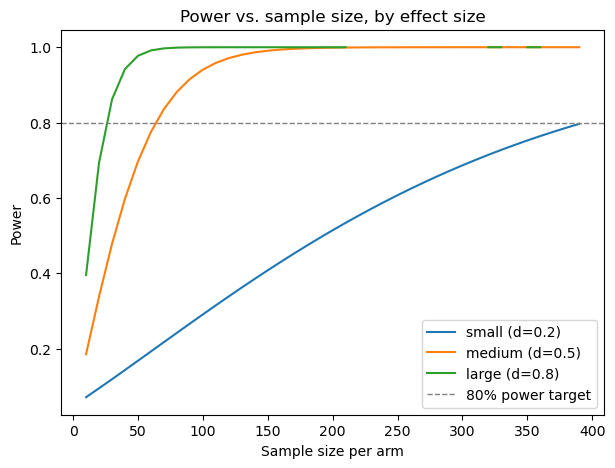

In [4]:
sample_sizes = np.arange(10, 400, 10)
effect_sizes = [0.2, 0.5, 0.8]
labels = ["small (d=0.2)", "medium (d=0.5)", "large (d=0.8)"]

fig, ax = plt.subplots(figsize=(7, 5))
for es, label in zip(effect_sizes, labels):
    powers = [power_analysis.power(effect_size=es, nobs1=n, alpha=alpha, ratio=1.0) for n in sample_sizes]
    ax.plot(sample_sizes, powers, label=label)

ax.axhline(0.8, color="gray", linestyle="--", linewidth=1, label="80% power target")
ax.set_xlabel("Sample size per arm")
ax.set_ylabel("Power")
ax.set_title("Power vs. sample size, by effect size")
ax.legend()
plt.show()

## Part 4 — Confirming it by simulation

The formula above is standard, but it can feel like a black box. Here's the same answer from Part 1, derived a different way: literally simulate thousands of fake two-arm experiments where we *know* the true effect size, run a t-test on each one, and count how often we correctly reject the null. That proportion *is* power, by definition — no formula required.

In [5]:
def simulate_power(effect_size, n_per_group, alpha=0.05, n_sims=5000, rng=rng):
    rejections = 0
    for _ in range(n_sims):
        control = rng.normal(loc=0.0, scale=1.0, size=n_per_group)
        treatment = rng.normal(loc=effect_size, scale=1.0, size=n_per_group)
        _, p_value = stats.ttest_ind(treatment, control)
        if p_value < alpha:
            rejections += 1
    return rejections / n_sims

simulated_power = simulate_power(effect_size=0.5, n_per_group=50)
print(f"Simulated power (5,000 runs): {simulated_power:.3f}")
print(f"Analytic power from Part 1:   {power:.3f}")

Simulated power (5,000 runs): 0.695
Analytic power from Part 1:   0.697


## Takeaways

- With *n* = 50 per arm and a true medium effect (*d* = 0.5), the simulation and the closed-form formula agree almost exactly — that agreement isn't a coincidence, it's what "power" means.
- To reliably (80%) detect that same medium effect, you need meaningfully more than 50 people per arm (see Part 2's `required_n` — and the power curve in Part 3 shows exactly where the small/medium/large curves cross the 80% line).
- Before running any real experiment, do this calculation with your best guess at the effect size (ideally from a pilot study or prior literature) before you commit resources to it.

**Try it yourself:** change `effect_size`, `alpha`, or `n_per_group` above and re-run — see how power responds. Once you're comfortable, try computing the required sample size for an effect size you'd actually expect in your own proposed experiment (see `assignments/short-writing/04-experiment-outline.md`).

---

## Your turn — unequal group sizes

Everything above assumed **equal** group sizes (`ratio=1.0`): the same number of people in treatment and control. In practice that's often not true — maybe treatment is expensive or hard to recruit for, but you can pull as many controls as you want from existing data.

`TTestIndPower` supports this via its `ratio` argument: `nobs1` is the size of one group (we'll use it for treatment), and `ratio` is `nobs2 / nobs1` (how many controls per treatment unit).

**The question:** if you're stuck with only 40 people in treatment, how much does piling on extra controls actually help — and how does that compare to just having 40 in *both* groups?

Compute power (`effect_size = 0.4`, `alpha = 0.05`) for these three scenarios:

1. `n_treatment = 40`, `ratio = 1` (40 controls, total *N* = 80)
2. `n_treatment = 40`, `ratio = 2` (80 controls, total *N* = 120)
3. `n_treatment = 40`, `ratio = 3` (120 controls, total *N* = 160)

Then compute power for an **equal-group** design with the *same total N* as scenario 2 — i.e. 60 and 60 — and compare it to scenario 2's power. Same total sample size, split differently: which design wins, and by how much?

No solution is provided here (see `PLAN.md` — the solutions pattern for this repo isn't decided yet). Write your code in the cell below; the print statements are there so you can see your own results.

In [6]:
effect_size_yt = 0.4
alpha_yt = 0.05
n_treatment = 40

# TODO: compute power for ratio = 1, 2, 3 using power_analysis.power(...)
# and print each one.


# TODO: compute power for an equal-group design with the same total N as
# the ratio=2 scenario (n_treatment=60, n_control=60) and print it.


# TODO: compare -- which design gets you more power for the same total N,
# lopsided (40 treatment / 80 control) or balanced (60 / 60)? Print or
# write a one-line comment with your answer.

**Reflection:** why do you think the result comes out the way it does? (Hint: which group's size is the "bottleneck" when the two groups are unequal, and what happens to it as you add more controls?)